# ASVspoof5 Train/Dev Logistic Baselines (A01-A16)

This notebook trains `16` separate binary logistic-regression models from prebuilt manifests:

- `train` source partition: `bonafide vs A01` ... `bonafide vs A08`
- `dev` source partition: `bonafide vs A09` ... `bonafide vs A16`

Expected input comes from a later `prepare_asvspoof5.ipynb` notebook that writes speaker-disjoint manifests for each source partition.

This notebook is partition-aware:
- `train` tasks read audio from `ASVspoof5_audio_train_tars`
- `dev` tasks read audio from `ASVspoof5_audio_dev_tars`


In [7]:
import gc
import io
import json
import pickle
import tarfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchaudio
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler


In [8]:
# ===== Config =====
PROJECT_ROOT = Path('/home/SpeakerRec/BioVoice')

PLAN_BASE = (
    PROJECT_ROOT
    / 'data'
    / 'datasets'
    / 'ASVspoof5_tars'
    / 'ASVspoof5_protocols'
    / 'train_dev_16_systems_outputs'
)

MANIFEST_SPECS = [
    {
        'source_partition': 'train',
        'manifest_path': PLAN_BASE / 'train' / 'selected_utterances_plan.csv',
        'tar_dir': PROJECT_ROOT / 'data' / 'datasets' / 'ASVspoof5_tars' / 'ASVspoof5_audio_train_tars',
        'target_systems': [f'A{i:02d}' for i in range(1, 9)],
        'tar_prefix': 'flac_T_*.tar',
    },
    {
        'source_partition': 'dev',
        'manifest_path': PLAN_BASE / 'dev' / 'selected_utterances_plan.csv',
        'tar_dir': PROJECT_ROOT / 'data' / 'datasets' / 'ASVspoof5_tars' / 'ASVspoof5_audio_dev_tars',
        'target_systems': [f'A{i:02d}' for i in range(9, 17)],
        'tar_prefix': 'flac_D_*.tar',
    },
]

OUT_BASE = PROJECT_ROOT / 'data' / 'models' / 'asvspoof5_train_dev_16_systems'
OUT_BASE.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
FORCE_RECOMPUTE_EMBEDDINGS = False
SAVE_PREDICTIONS = True
LOGREG_MAX_ITER = 2000
LOGREG_C = 1.0

print('DEVICE =', DEVICE)
print('PLAN_BASE =', PLAN_BASE)
print('OUT_BASE =', OUT_BASE)
for spec in MANIFEST_SPECS:
    print(spec['source_partition'], 'manifest =', spec['manifest_path'], '| exists =', spec['manifest_path'].exists())
    print(spec['source_partition'], 'tar_dir =', spec['tar_dir'], '| exists =', spec['tar_dir'].exists())


DEVICE = cuda
PLAN_BASE = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols/train_dev_16_systems_outputs
OUT_BASE = /home/SpeakerRec/BioVoice/data/models/asvspoof5_train_dev_16_systems
train manifest = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols/train_dev_16_systems_outputs/train/selected_utterances_plan.csv | exists = True
train tar_dir = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_audio_train_tars | exists = True
dev manifest = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols/train_dev_16_systems_outputs/dev/selected_utterances_plan.csv | exists = True
dev tar_dir = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_audio_dev_tars | exists = True


In [9]:
# ===== Model =====
redim_model = (
    torch.hub.load(
        'IDRnD/ReDimNet',
        'ReDimNet',
        model_name='b6',
        train_type='ptn',
        dataset='vox2',
    )
    .to(DEVICE)
    .eval()
)
print('Loaded ReDimNet on', DEVICE)


Using cache found in /home/SpeakerRec/.cache/torch/hub/IDRnD_ReDimNet_master


Loaded ReDimNet on cuda


In [10]:
def embed_waveform(wav: torch.Tensor, sr: int) -> np.ndarray:
    if sr != 16000:
        wav = torchaudio.functional.resample(wav, sr, 16000)
    if wav.ndim == 1:
        wav = wav.unsqueeze(0)
    if wav.shape[0] > 1:
        wav = wav[:1, :]
    wav = wav.to(DEVICE)
    with torch.no_grad():
        emb = redim_model(wav)
    return emb.squeeze(0).detach().cpu().numpy().astype(np.float32)


def embed_member_from_tar(tf: tarfile.TarFile, member: tarfile.TarInfo) -> np.ndarray:
    fobj = tf.extractfile(member)
    if fobj is None:
        raise RuntimeError(f'Cannot extract member: {member.name}')
    raw = fobj.read()
    try:
        wav, sr = torchaudio.load(io.BytesIO(raw))
    except Exception:
        import tempfile
        suffix = Path(member.name).suffix or '.flac'
        with tempfile.NamedTemporaryFile(suffix=suffix, delete=True) as tmp:
            tmp.write(raw)
            tmp.flush()
            wav, sr = torchaudio.load(tmp.name)
    return embed_waveform(wav, sr)


def extract_embeddings_for_manifest(manifest_df: pd.DataFrame, cache_npz: Path, tar_dir: Path, tar_prefix: str, force_recompute: bool=False):
    if cache_npz.exists() and not force_recompute:
        payload = np.load(cache_npz, allow_pickle=True)
        X = payload['X']
        utt_ids = payload['utt_ids'].astype(str)
        lut = pd.DataFrame({'utt_id': utt_ids, '_idx': np.arange(len(utt_ids))})
        m = manifest_df[['utt_id']].astype(str).merge(lut, on='utt_id', how='left', validate='one_to_one')
        if m['_idx'].isna().any():
            miss = m.loc[m['_idx'].isna(), 'utt_id'].tolist()[:10]
            raise RuntimeError(f'Embedding cache missing utt_ids, examples={miss}')
        return X[m['_idx'].astype(int).to_numpy()]

    tars = sorted(tar_dir.glob(tar_prefix))
    assert len(tars) > 0, f'No tar files in {tar_dir} matching {tar_prefix}'

    need = set(manifest_df['utt_id'].astype(str).tolist())
    emb_map = {}
    found = set()

    for tar_path in tars:
        print('Reading', tar_path.name)
        with tarfile.open(tar_path, 'r') as tf:
            for member in tf:
                if not member.isfile():
                    continue
                utt = Path(Path(member.name).name).stem
                if utt not in need or utt in found:
                    continue
                emb_map[utt] = embed_member_from_tar(tf, member)
                found.add(utt)
        print('Found so far:', len(found), '/', len(need))

    missing = sorted(list(need - found))
    if missing:
        raise RuntimeError(f'Missing {len(missing)} utt_ids in tar shards. examples={missing[:10]}')

    ids = manifest_df['utt_id'].astype(str).tolist()
    X = np.stack([emb_map[u] for u in ids]).astype(np.float32)
    np.savez_compressed(cache_npz, X=X, utt_ids=np.array(ids, dtype=object))
    return X


In [11]:
def compute_metrics(y_true, p_spoof, thr=0.5):
    y_hat = (p_spoof >= thr).astype(int)
    cm = confusion_matrix(y_true, y_hat).tolist()
    return {
        'accuracy': float(accuracy_score(y_true, y_hat)),
        'auc': float(roc_auc_score(y_true, p_spoof)) if len(np.unique(y_true)) == 2 else None,
        'confusion_matrix': cm,
        'classification_report': classification_report(y_true, y_hat, output_dict=True, zero_division=0),
    }


def validate_manifest(df: pd.DataFrame, source_partition: str):
    req_cols = {'split', 'speaker_id', 'utt_id', 'gender', 'label', 'system_id', 'sample_class', 'target_class'}
    missing = req_cols - set(df.columns)
    if missing:
        raise ValueError(f'{source_partition} manifest missing cols: {sorted(missing)}')
    if 'source_partition' in df.columns:
        bad = df.loc[~df['source_partition'].eq(source_partition)]
        if len(bad) > 0:
            raise ValueError(f'{source_partition} manifest contains mismatched source_partition rows')
    if set(df['split'].unique()) - {'train', 'test'}:
        raise ValueError(f'{source_partition} manifest split column must only contain train/test')


In [12]:
all_summary_rows = []

for spec in MANIFEST_SPECS:
    source_partition = spec['source_partition']
    manifest_path = spec['manifest_path']
    tar_dir = spec['tar_dir']
    tar_prefix = spec['tar_prefix']
    target_systems = spec['target_systems']

    print(f'===== SOURCE PARTITION: {source_partition.upper()} =====')
    assert manifest_path.exists(), f'Missing manifest: {manifest_path}'

    part_dir = OUT_BASE / source_partition
    part_dir.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(manifest_path)
    validate_manifest(df, source_partition)

    cache_npz = part_dir / 'embeddings_all_selected.npz'
    X_all = extract_embeddings_for_manifest(
        df[['utt_id']].copy(),
        cache_npz=cache_npz,
        tar_dir=tar_dir,
        tar_prefix=tar_prefix,
        force_recompute=FORCE_RECOMPUTE_EMBEDDINGS,
    )

    (part_dir / 'manifest_snapshot.csv').write_text(df.head(200).to_csv(index=False), encoding='utf-8')

    idx_map = pd.DataFrame({'utt_id': df['utt_id'].astype(str), '_idx': np.arange(len(df))})

    for sys_id in target_systems:
        print(f'-- Task bonafide vs {sys_id}')
        task_df = df[df['target_class'].isin(['bonafide', sys_id])].copy().reset_index(drop=True)
        assert not task_df.empty, f'Empty task data for {source_partition}/{sys_id}'

        pick = task_df[['utt_id']].astype(str).merge(idx_map, on='utt_id', how='left', validate='one_to_one')
        if pick['_idx'].isna().any():
            raise RuntimeError(f'Index mapping failed for {source_partition}/{sys_id}')

        X = X_all[pick['_idx'].astype(int).to_numpy()]
        y = np.where(task_df['target_class'].eq('bonafide'), 0, 1).astype(int)

        is_train = task_df['split'].eq('train').to_numpy()
        is_test = task_df['split'].eq('test').to_numpy()
        X_tr, y_tr = X[is_train], y[is_train]
        X_te, y_te = X[is_test], y[is_test]

        assert len(X_tr) > 0 and len(X_te) > 0, f'Empty split for {source_partition}/{sys_id}'
        assert set(np.unique(y_tr)) == {0, 1}, f'Train labels invalid for {source_partition}/{sys_id}'
        assert set(np.unique(y_te)) == {0, 1}, f'Test labels invalid for {source_partition}/{sys_id}'

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        clf = LogisticRegression(
            max_iter=LOGREG_MAX_ITER,
            C=LOGREG_C,
            class_weight=None,
            random_state=42,
            n_jobs=-1,
        )
        clf.fit(X_tr_s, y_tr)

        p_tr = clf.predict_proba(X_tr_s)[:, 1]
        p_te = clf.predict_proba(X_te_s)[:, 1]

        m_tr = compute_metrics(y_tr, p_tr, thr=0.5)
        m_te = compute_metrics(y_te, p_te, thr=0.5)

        task_dir = part_dir / sys_id
        task_dir.mkdir(parents=True, exist_ok=True)
        with open(task_dir / 'scaler.pkl', 'wb') as f:
            pickle.dump(scaler, f)
        with open(task_dir / 'logistic_regression.pkl', 'wb') as f:
            pickle.dump(clf, f)

        run_summary = {
            'source_partition': source_partition,
            'task': f'bonafide_vs_{sys_id}',
            'task_system_id': sys_id,
            'train_rows': int(len(task_df[task_df['split'].eq('train')])),
            'test_rows': int(len(task_df[task_df['split'].eq('test')])),
            'train_bonafide_rows': int(((task_df['split'].eq('train')) & (task_df['target_class'].eq('bonafide'))).sum()),
            'train_spoof_rows': int(((task_df['split'].eq('train')) & (task_df['target_class'].eq(sys_id))).sum()),
            'test_bonafide_rows': int(((task_df['split'].eq('test')) & (task_df['target_class'].eq('bonafide'))).sum()),
            'test_spoof_rows': int(((task_df['split'].eq('test')) & (task_df['target_class'].eq(sys_id))).sum()),
            'train_acc': m_tr['accuracy'],
            'train_auc': m_tr['auc'],
            'train_cm': m_tr['confusion_matrix'],
            'test_acc': m_te['accuracy'],
            'test_auc': m_te['auc'],
            'test_cm': m_te['confusion_matrix'],
        }
        with open(task_dir / 'run_summary.json', 'w', encoding='utf-8') as f:
            json.dump(run_summary, f, indent=2)

        if SAVE_PREDICTIONS:
            pred_df = task_df[['split', 'speaker_id', 'utt_id', 'gender', 'label', 'system_id', 'sample_class', 'target_class']].copy()
            pred_df['y_true'] = y
            pred_df['p_spoof'] = np.concatenate([p_tr, p_te])
            pred_df['y_hat'] = (pred_df['p_spoof'] >= 0.5).astype(int)
            pred_df.to_csv(task_dir / 'predictions.csv', index=False)

        all_summary_rows.append(run_summary)

        print({
            'source_partition': source_partition,
            'task': sys_id,
            'train_rows': run_summary['train_rows'],
            'test_rows': run_summary['test_rows'],
            'test_acc': round(run_summary['test_acc'], 4),
            'test_auc': None if run_summary['test_auc'] is None else round(run_summary['test_auc'], 4),
            'test_cm': run_summary['test_cm'],
        })

        del scaler, clf, X, X_tr, X_te, X_tr_s, X_te_s, task_df, pick, p_tr, p_te
        gc.collect()

summary_df = pd.DataFrame(all_summary_rows).sort_values(['source_partition', 'task_system_id']).reset_index(drop=True)
summary_csv = OUT_BASE / 'metrics_summary.csv'
summary_df.to_csv(summary_csv, index=False)
print('Saved summary ->', summary_csv)
display(summary_df)


===== SOURCE PARTITION: TRAIN =====
-- Task bonafide vs A01
{'source_partition': 'train', 'task': 'A01', 'train_rows': 18454, 'test_rows': 8950, 'test_acc': 0.9924, 'test_auc': 0.9997, 'test_cm': [[4421, 54], [14, 4461]]}
-- Task bonafide vs A02
{'source_partition': 'train', 'task': 'A02', 'train_rows': 18454, 'test_rows': 8950, 'test_acc': 0.9974, 'test_auc': 1.0, 'test_cm': [[4453, 22], [1, 4474]]}
-- Task bonafide vs A03
{'source_partition': 'train', 'task': 'A03', 'train_rows': 18454, 'test_rows': 8950, 'test_acc': 0.9978, 'test_auc': 1.0, 'test_cm': [[4455, 20], [0, 4475]]}
-- Task bonafide vs A04
{'source_partition': 'train', 'task': 'A04', 'train_rows': 18454, 'test_rows': 8950, 'test_acc': 0.9981, 'test_auc': 1.0, 'test_cm': [[4463, 12], [5, 4470]]}
-- Task bonafide vs A05
{'source_partition': 'train', 'task': 'A05', 'train_rows': 18454, 'test_rows': 8950, 'test_acc': 0.998, 'test_auc': 1.0, 'test_cm': [[4461, 14], [4, 4471]]}
-- Task bonafide vs A06
{'source_partition': 'train

,source_partition,task,task_system_id,train_rows,test_rows,train_bonafide_rows,train_spoof_rows,test_bonafide_rows,test_spoof_rows,train_acc,train_auc,train_cm,test_acc,test_auc,test_cm
0,dev,bonafide_vs_A09,A09,18454,8950,9227,9227,4475,4475,1.000000,1.000000,"[[9227, 0], [0, 9227]]",0.996201,0.999936,"[[4445, 30], [4, 4471]]"
1,dev,bonafide_vs_A10,A10,18454,8950,9227,9227,4475,4475,1.000000,1.000000,"[[9227, 0], [0, 9227]]",0.995084,0.999941,"[[4433, 42], [2, 4473]]"
2,dev,bonafide_vs_A11,A11,18454,8950,9227,9227,4475,4475,1.000000,1.000000,"[[9227, 0], [0, 9227]]",0.999665,1.000000,"[[4473, 2], [1, 4474]]"
3,dev,bonafide_vs_A12,A12,18454,8950,9227,9227,4475,4475,0.954427,0.991831,"[[8838, 389], [452, 8775]]",0.897654,0.963575,"[[3940, 535], [381, 4094]]"
4,dev,bonafide_vs_A13,A13,18454,8950,9227,9227,4475,4475,1.000000,1.000000,"[[9227, 0], [0, 9227]]",0.995866,0.999939,"[[4443, 32], [5, 4470]]"
5,dev,bonafide_vs_A14,A14,18454,8950,9227,9227,4475,4475,1.000000,1.000000,"[[9227, 0], [0, 9227]]",1.000000,1.000000,"[[4475, 0], [0, 4475]]"
6,dev,bonafide_vs_A15,A15,18454,8950,9227,9227,4475,4475,1.000000,1.000000,"[[9227, 0], [0, 9227]]",0.996872,0.999976,"[[4448, 27], [1, 4474]]"
7,dev,bonafide_vs_A16,A16,18454,8950,9227,9227,4475,4475,1.000000,1.000000,"[[9227, 0], [0, 9227]]",0.998994,0.999997,"[[4466, 9], [0, 4475]]"
8,train,bonafide_vs_A01,A01,18454,8950,9227,9227,4475,4475,1.000000,1.000000,"[[9227, 0], [0, 9227]]",0.992402,0.999706,"[[4421, 54], [14, 4461]]"
9,train,bonafide_vs_A02,A02,18454,8950,9227,9227,4475,4475,1.000000,1.000000,"[[9227, 0], [0, 9227]]",0.997430,0.999982,"[[4453, 22], [1, 4474]]"


In [13]:
summary_df = pd.read_csv(OUT_BASE / 'metrics_summary.csv')
display(summary_df)


,source_partition,task,task_system_id,train_rows,test_rows,train_bonafide_rows,train_spoof_rows,test_bonafide_rows,test_spoof_rows,train_acc,train_auc,train_cm,test_acc,test_auc,test_cm
0,dev,bonafide_vs_A09,A09,18454,8950,9227,9227,4475,4475,1.000000,1.000000,"[[9227, 0], [0, 9227]]",0.996201,0.999936,"[[4445, 30], [4, 4471]]"
1,dev,bonafide_vs_A10,A10,18454,8950,9227,9227,4475,4475,1.000000,1.000000,"[[9227, 0], [0, 9227]]",0.995084,0.999941,"[[4433, 42], [2, 4473]]"
2,dev,bonafide_vs_A11,A11,18454,8950,9227,9227,4475,4475,1.000000,1.000000,"[[9227, 0], [0, 9227]]",0.999665,1.000000,"[[4473, 2], [1, 4474]]"
3,dev,bonafide_vs_A12,A12,18454,8950,9227,9227,4475,4475,0.954427,0.991831,"[[8838, 389], [452, 8775]]",0.897654,0.963575,"[[3940, 535], [381, 4094]]"
4,dev,bonafide_vs_A13,A13,18454,8950,9227,9227,4475,4475,1.000000,1.000000,"[[9227, 0], [0, 9227]]",0.995866,0.999939,"[[4443, 32], [5, 4470]]"
5,dev,bonafide_vs_A14,A14,18454,8950,9227,9227,4475,4475,1.000000,1.000000,"[[9227, 0], [0, 9227]]",1.000000,1.000000,"[[4475, 0], [0, 4475]]"
6,dev,bonafide_vs_A15,A15,18454,8950,9227,9227,4475,4475,1.000000,1.000000,"[[9227, 0], [0, 9227]]",0.996872,0.999976,"[[4448, 27], [1, 4474]]"
7,dev,bonafide_vs_A16,A16,18454,8950,9227,9227,4475,4475,1.000000,1.000000,"[[9227, 0], [0, 9227]]",0.998994,0.999997,"[[4466, 9], [0, 4475]]"
8,train,bonafide_vs_A01,A01,18454,8950,9227,9227,4475,4475,1.000000,1.000000,"[[9227, 0], [0, 9227]]",0.992402,0.999706,"[[4421, 54], [14, 4461]]"
9,train,bonafide_vs_A02,A02,18454,8950,9227,9227,4475,4475,1.000000,1.000000,"[[9227, 0], [0, 9227]]",0.997430,0.999982,"[[4453, 22], [1, 4474]]"


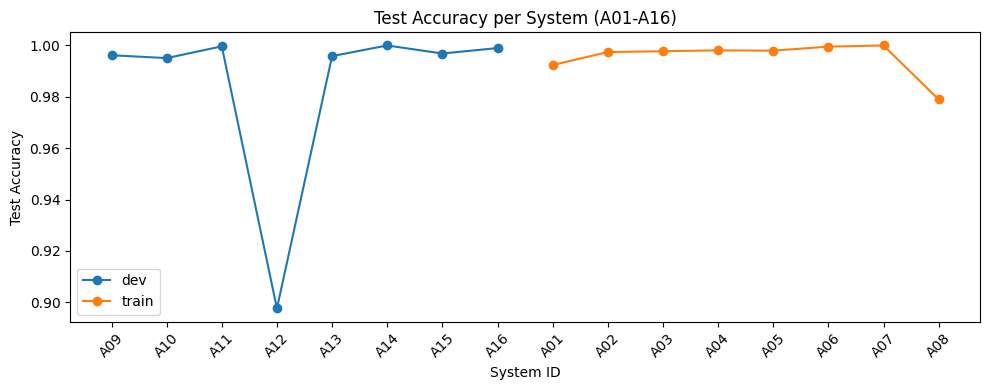

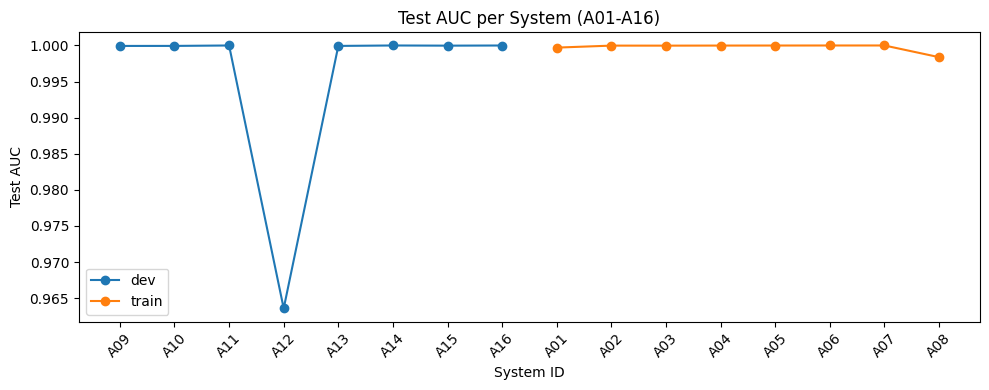

In [14]:
plt.figure(figsize=(10, 4))
for part in summary_df['source_partition'].unique():
    sub = summary_df[summary_df['source_partition'] == part]
    plt.plot(sub['task_system_id'], sub['test_acc'], marker='o', label=part)
plt.xlabel('System ID')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy per System (A01-A16)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
for part in summary_df['source_partition'].unique():
    sub = summary_df[summary_df['source_partition'] == part]
    plt.plot(sub['task_system_id'], sub['test_auc'], marker='o', label=part)
plt.xlabel('System ID')
plt.ylabel('Test AUC')
plt.title('Test AUC per System (A01-A16)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
